In [2]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_grid(L, Nx):
    
    return np.linspace(-L/2, L/2 , Nx, endpoint=False)


def thickness_profile(x, Lambda, duty, d0, h):
    
    phase_in_period = ((x) % Lambda) / Lambda
    d = d0 + h * (phase_in_period < duty).astype(float)
    return d


def phase_signal(d, n, lam):
    
    k = 2*np.pi/lam
    return n * k * d


import numpy as np

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

def plot_signal(x, f):
    
    plt.figure()
    plt.plot(x*1e6, f)
    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title("Phase Signal")
    plt.grid(True)
    plt.show()


Running for 6 qubits (Nx = 64)


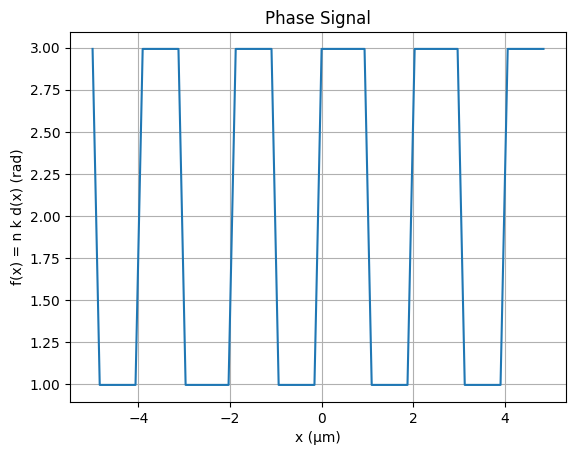


Running for 7 qubits (Nx = 128)


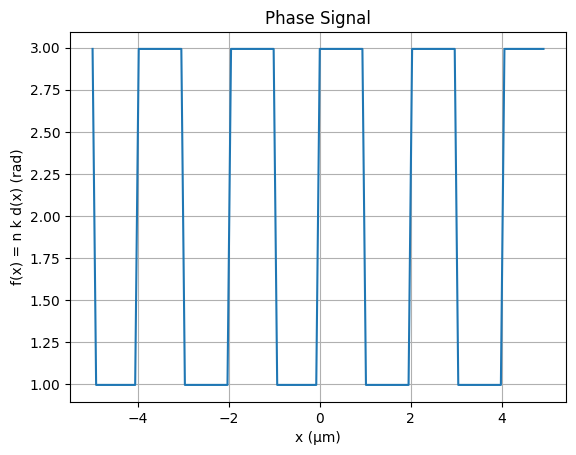


Running for 8 qubits (Nx = 256)


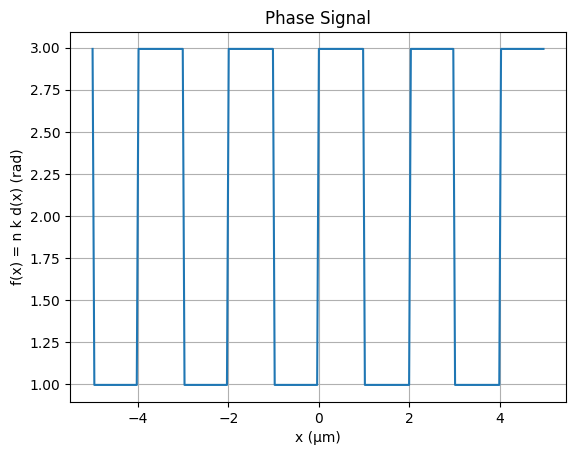


Running for 9 qubits (Nx = 512)


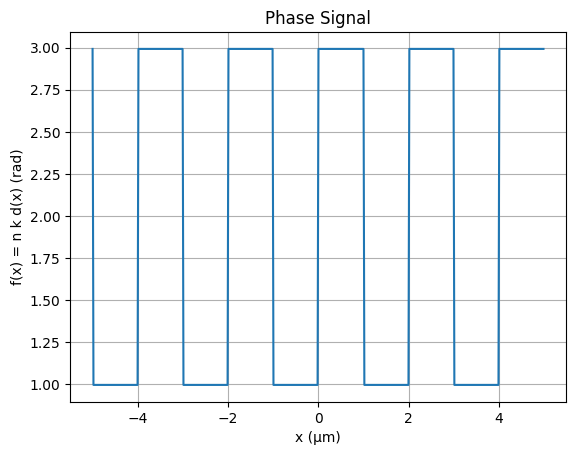


Running for 10 qubits (Nx = 1024)


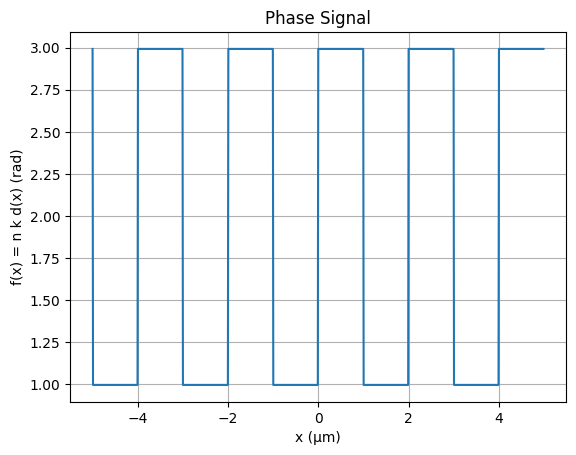


Running for 11 qubits (Nx = 2048)


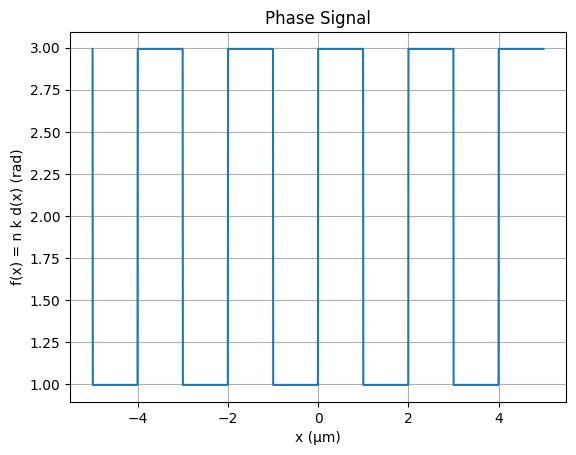


Running for 12 qubits (Nx = 4096)


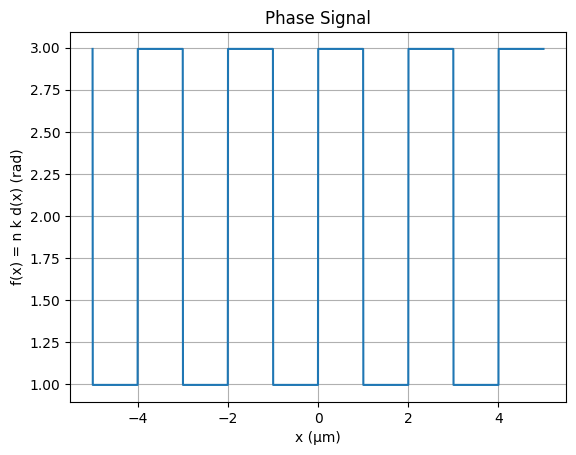

In [3]:
# spatial parameters
T = 10e-6

# optical parameters
lam = 630e-9
n_refr = 1.0   # avoid conflict with qubit n

# grating parameters
Lambda = 2e-6
duty = 0.50
d0 = 100e-9
h = 200e-9

for n_qubits in range(6, 13):   # 6 → 12 qubits
    Nx = 2**n_qubits

    print(f"\nRunning for {n_qubits} qubits (Nx = {Nx})")

    x = spatial_grid(T, Nx)

    d = thickness_profile(x, Lambda, duty, d0, h)

    f = phase_signal(d, n_refr, lam)

    phi, alpha = phi_from_f(f)

    plot_signal(x, f)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity

sim = AerSimulator(method="statevector")

qubit_range = range(5, 10)      # 5, 6, 7, 8, 9 qubits
layer_range = range(1, 201)     # 1 to 200 layers
threshold = 0.99

best_layers = []
best_fidelities = []

for n_qubits in qubit_range:

    Nx = 2**n_qubits

    x = spatial_grid(T, Nx)
    d = thickness_profile(x, Lambda, duty, d0, h)
    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    print(f"\nRunning for {n_qubits} qubits")

    reached_threshold = False

    for L in layer_range:

        phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
        U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

        qc = QuantumCircuit(n_qubits)
        qc.append(U_phi, range(n_qubits))
        qc.save_statevector()

        result = sim.run(transpile(qc, sim)).result()
        vec_sim = np.array(result.get_statevector(qc), dtype=complex)

        F = state_fidelity(vec_sim, phi)

        print(f"  Layers = {L}, Fidelity = {F:.6f}")

        if F >= threshold:
            print(f"  ✅ Threshold reached at layer {L}, Fidelity = {F:.6f}")
            best_layers.append(L)
            best_fidelities.append(F)
            reached_threshold = True
            break

    if not reached_threshold:
        print(f"  ❌ Threshold not reached up to 200 layers")
        best_layers.append(np.nan)
        best_fidelities.append(np.nan)


Running for 5 qubits
  Layers = 1, Fidelity = 0.981322
  Layers = 2, Fidelity = 0.993118
  ✅ Threshold reached at layer 2, Fidelity = 0.993118

Running for 6 qubits
  Layers = 1, Fidelity = 0.962930
  Layers = 2, Fidelity = 0.985746
  Layers = 3, Fidelity = 0.988820
  Layers = 4, Fidelity = 0.984050
  Layers = 5, Fidelity = 0.994893
  ✅ Threshold reached at layer 5, Fidelity = 0.994893

Running for 7 qubits
  Layers = 1, Fidelity = 0.959238
  Layers = 2, Fidelity = 0.983386
  Layers = 3, Fidelity = 0.972029
  Layers = 4, Fidelity = 0.978151
  Layers = 5, Fidelity = 0.942516
  Layers = 6, Fidelity = 0.966683
  Layers = 7, Fidelity = 0.958148
  Layers = 8, Fidelity = 0.960419
  Layers = 9, Fidelity = 0.969959
  Layers = 10, Fidelity = 0.971736
  Layers = 11, Fidelity = 0.968622
  Layers = 12, Fidelity = 0.965255
  Layers = 13, Fidelity = 0.972818
  Layers = 14, Fidelity = 0.972910
  Layers = 15, Fidelity = 0.975963
  Layers = 16, Fidelity = 0.964866
  Layers = 17, Fidelity = 0.972633
  

Used for fitting:
Qubits = 5, Layers = 2.0
Qubits = 6, Layers = 5.0
Qubits = 7, Layers = 70.0
Qubits = 8, Layers = 145.0

Fit quality:
Linear R² = 0.8950194381280716
Quadratic R² = 0.9900828871121543
Exponential R² = 0.963108422654188


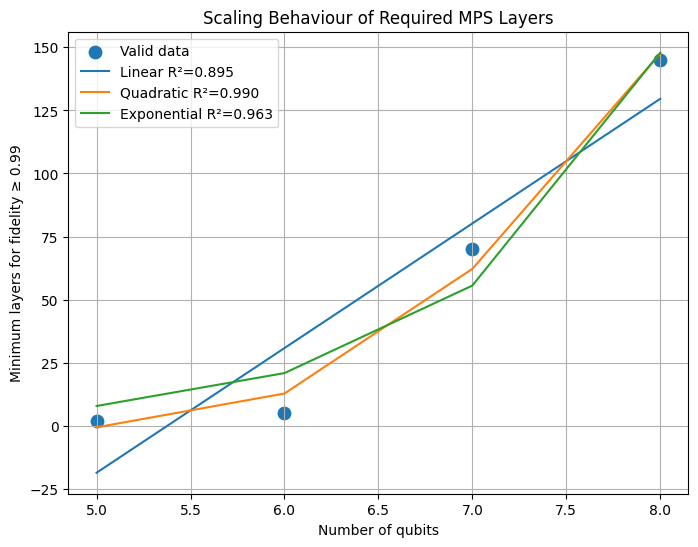

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

x = np.array(list(qubit_range), dtype=float)
y = np.array(best_layers, dtype=float)

# remove NaN values
mask = np.isfinite(y)

x_fit = x[mask]
y_fit = y[mask]

print("Used for fitting:")
for q, L in zip(x_fit, y_fit):
    print(f"Qubits = {int(q)}, Layers = {L}")

# Linear fit
linear_coeff = np.polyfit(x_fit, y_fit, 1)
linear_model = np.poly1d(linear_coeff)
y_linear = linear_model(x_fit)

# Quadratic fit
quad_coeff = np.polyfit(x_fit, y_fit, 2)
quad_model = np.poly1d(quad_coeff)
y_quad = quad_model(x_fit)

# Exponential fit
def exp_func(x, A, B):
    return A * np.exp(B * x)

params, _ = curve_fit(exp_func, x_fit, y_fit, maxfev=10000)
y_exp = exp_func(x_fit, *params)

# R² scores
r2_linear = r2_score(y_fit, y_linear)
r2_quad = r2_score(y_fit, y_quad)
r2_exp = r2_score(y_fit, y_exp)

print("\nFit quality:")
print("Linear R² =", r2_linear)
print("Quadratic R² =", r2_quad)
print("Exponential R² =", r2_exp)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(x_fit, y_fit, s=80, label="Valid data")

plt.plot(x_fit, y_linear, label=f"Linear R²={r2_linear:.3f}")
plt.plot(x_fit, y_quad, label=f"Quadratic R²={r2_quad:.3f}")
plt.plot(x_fit, y_exp, label=f"Exponential R²={r2_exp:.3f}")

plt.xlabel("Number of qubits")
plt.ylabel("Minimum layers for fidelity ≥ 0.99")
plt.title("Scaling Behaviour of Required MPS Layers")
plt.legend()
plt.grid(True)
plt.show()

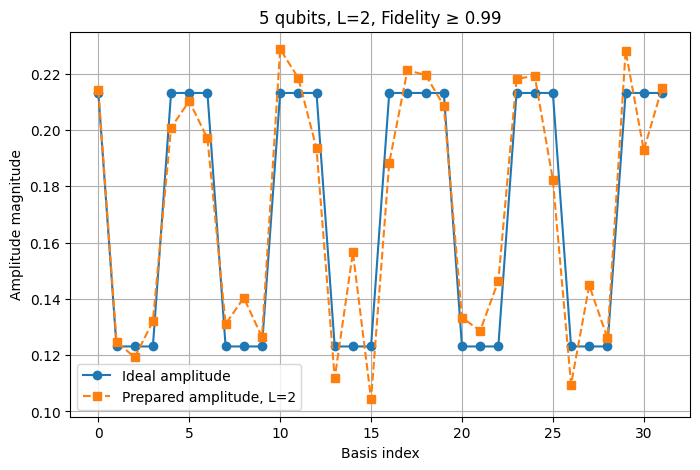

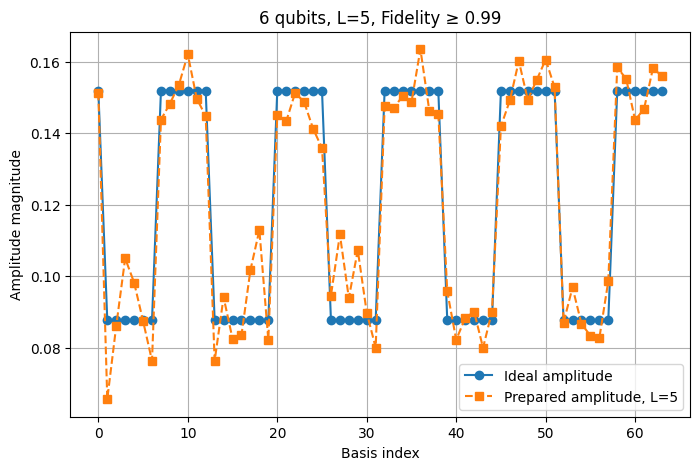

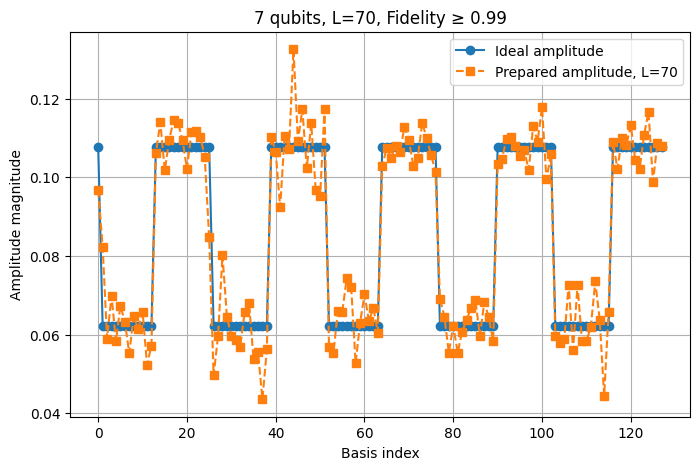

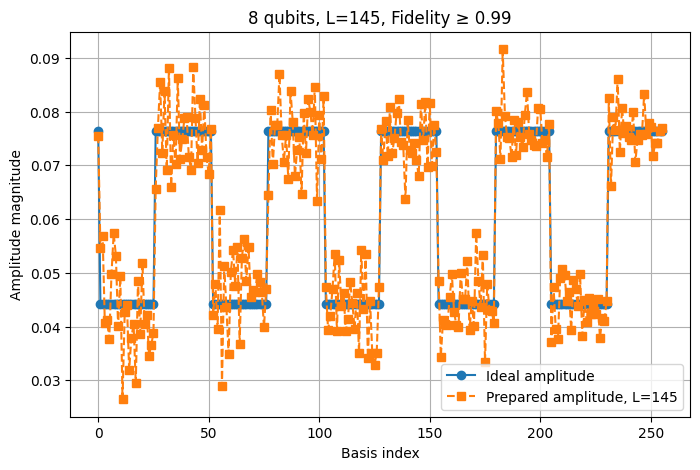

9 qubits: fidelity 0.99 not reached.


In [12]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState

sim = AerSimulator(method="statevector")

for qi, n_qubits in enumerate(qubit_range):
    chosen_layer = best_layers[qi]

    if np.isnan(chosen_layer):
        print(f"{n_qubits} qubits: fidelity {threshold} not reached.")
        continue

    Nx = 2**n_qubits

    # regenerate phi for this qubit count
    x = spatial_grid(T,Nx)
    d = thickness_profile(x, Lambda, duty, d0, h)
    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    # build threshold-layer circuit
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=int(chosen_layer))

    qc = QuantumCircuit(n_qubits)
    qc.append(U_phi, range(n_qubits))
    qc.save_statevector()

    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # align global phase
    global_phase = np.angle(np.vdot(phi, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    amps_ideal = np.abs(phi)
    amps_sim = np.abs(vec_sim_aligned)

    plt.figure(figsize=(8, 5))
    plt.plot(range(Nx), amps_ideal, 'o-', label="Ideal amplitude")
    plt.plot(range(Nx), amps_sim, 's--', label=f"Prepared amplitude, L={int(chosen_layer)}")
    plt.xlabel("Basis index")
    plt.ylabel("Amplitude magnitude")
    plt.title(f"{n_qubits} qubits, L={int(chosen_layer)}, Fidelity ≥ {threshold}")
    plt.legend()
    plt.grid(True)
    plt.show()